In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

In [12]:
import os

print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

Current folder: /Users/eniyamadden/Final-Project--1/notebooks
Files here: ['results', 'logistic_regression.ipynb', 'random_forest.ipynb']


In [13]:
data_dir = "../data/final_project_data_sp2026_L"

csv_files = [
    os.path.join(data_dir, "ids_0.csv"),
    os.path.join(data_dir, "ids_1.csv"),
    os.path.join(data_dir, "ids_2.csv"),
    os.path.join(data_dir, "ids_4_.csv"),
]

parquet_files = [
    os.path.join(data_dir, "ids_5.parquet"),
    os.path.join(data_dir, "ids_6.parquet"),
    os.path.join(data_dir, "ids_8.parquet"),
    os.path.join(data_dir, "ids_11.parquet"),
]

dfs = []

for f in csv_files:
    temp = pd.read_csv(f)
    temp.columns = temp.columns.str.strip()
    dfs.append(temp)

for f in parquet_files:
    temp = pd.read_parquet(f)
    temp.columns = temp.columns.str.strip()
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True, sort=False)

print(df["Label"].value_counts())
print(df["Label"].unique())



Label
DoS Hulk         21027
DoS GoldenEye    10293
BENIGN            4004
Name: count, dtype: int64
['BENIGN' 'DoS Hulk' 'DoS GoldenEye']


In [14]:
display(df)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,61205,4,2,136,428,34,34,34.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,222,2,2,90,172,45,45,45.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53,23759,2,2,70,126,35,35,35.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,80,401,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,57406,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35319,80,101304725,7,6,1110,11595,366,0,158.571429,194.047122,...,20,3986.0,0.0,3986,3986,101000000.0,0.0,101000000,101000000,DoS Hulk
35320,80,144456,3,6,333,11595,333,0,111.000000,192.257640,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
35321,80,99934662,5,7,315,11595,303,0,63.000000,134.197616,...,20,10008.0,0.0,10008,10008,99900000.0,0.0,99900000,99900000,DoS Hulk
35322,80,86074100,6,8,431,11595,413,0,71.833333,167.162695,...,20,11997.0,0.0,11997,11997,85900000.0,0.0,85900000,85900000,DoS Hulk


In [15]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35324 entries, 0 to 35323
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             35324 non-null  int64  
 1   Flow Duration                35324 non-null  int64  
 2   Total Fwd Packets            35324 non-null  int64  
 3   Total Backward Packets       35324 non-null  int64  
 4   Total Length of Fwd Packets  35324 non-null  int64  
 5   Total Length of Bwd Packets  35324 non-null  int64  
 6   Fwd Packet Length Max        35324 non-null  int64  
 7   Fwd Packet Length Min        35324 non-null  int64  
 8   Fwd Packet Length Mean       35324 non-null  float64
 9   Fwd Packet Length Std        35324 non-null  float64
 10  Bwd Packet Length Max        35324 non-null  int64  
 11  Bwd Packet Length Min        35324 non-null  int64  
 12  Bwd Packet Length Mean       35324 non-null  float64
 13  Bwd Packet Lengt

/Users/eniyamadden/.pyenv/versions/3.10.13/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/eniyamadden/.pyenv/versions/3.10.13/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,35324.000000,3.532400e+04,35324.000000,35324.000000,35324.000000,3.532400e+04,35324.000000,35324.000000,35324.000000,35324.000000,...,35324.000000,35324.000000,3.532400e+04,3.532400e+04,3.532400e+04,3.532400e+04,3.532400e+04,3.532400e+04,3.532400e+04,3.532400e+04
mean,1203.752548,4.217434e+07,6.762569,5.931435,399.455951,1.075409e+04,258.691824,2.535557,52.029713,104.236133,...,2.632969,28.664930,7.052138e+04,1.419158e+04,8.791439e+04,6.153310e+04,3.931697e+07,5.538478e+05,3.971454e+07,3.891569e+07
std,7437.161180,4.399691e+07,139.226812,189.397082,2893.066268,4.242184e+05,317.537827,16.209431,81.108565,126.229514,...,137.232841,5.433104,5.222983e+05,2.319484e+05,6.436837e+05,4.897209e+05,4.390458e+07,5.575378e+06,4.422689e+07,4.394162e+07
min,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,2.862825e+04,2.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,1.185260e+07,6.000000,5.000000,337.000000,1.159500e+04,326.000000,0.000000,47.000000,124.450794,...,1.000000,32.000000,5.000000e+00,0.000000e+00,5.000000e+00,5.000000e+00,6.839338e+06,0.000000e+00,6.839338e+06,6.801360e+06
75%,80.000000,8.678486e+07,8.000000,6.000000,387.000000,1.159500e+04,370.000000,0.000000,65.600000,153.870725,...,2.000000,32.000000,1.070000e+03,0.000000e+00,1.070000e+03,1.057000e+03,8.550000e+07,0.000000e+00,8.570000e+07,8.550000e+07
max,64249.000000,1.199997e+08,18649.000000,25335.000000,312775.000000,5.610000e+07,11595.000000,1399.000000,2319.000000,5185.441640,...,18392.000000,56.000000,1.370000e+07,1.180000e+07,2.410000e+07,1.370000e+07,1.200000e+08,6.070000e+07,1.200000e+08,1.200000e+08


In [16]:
def transform_data(df):
    df = df.drop_duplicates().copy()
    df["Label"] = df["Label"].str.strip()

    # remove Heartbleed
    df = df[df["Label"] != "Heartbleed"].copy()

    # binary labels
    df["Label"] = df["Label"].apply(
        lambda x: "benign" if x.lower() == "benign" else "attack"
    )

    print("\nBinary labels:")
    print(df["Label"].value_counts())

    x = df.drop(columns=["Label"])
    y = df["Label"]

    return x, y, df

In [17]:
def remove_outliers_iqr(df):
    df = df.copy()

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # calculate IQR correctly
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    for col in numeric_cols:
        median = df[col].median()
        df[col] = np.where(
            (df[col] < lower_bound[col]) | (df[col] > upper_bound[col]),
            median,
            df[col]
        )

    return df

In [18]:
x, y, df_clean = transform_data(df)

print(x.shape)
print(y.shape)


Binary labels:
Label
attack    25630
benign     2971
Name: count, dtype: int64
(28601, 78)
(28601,)


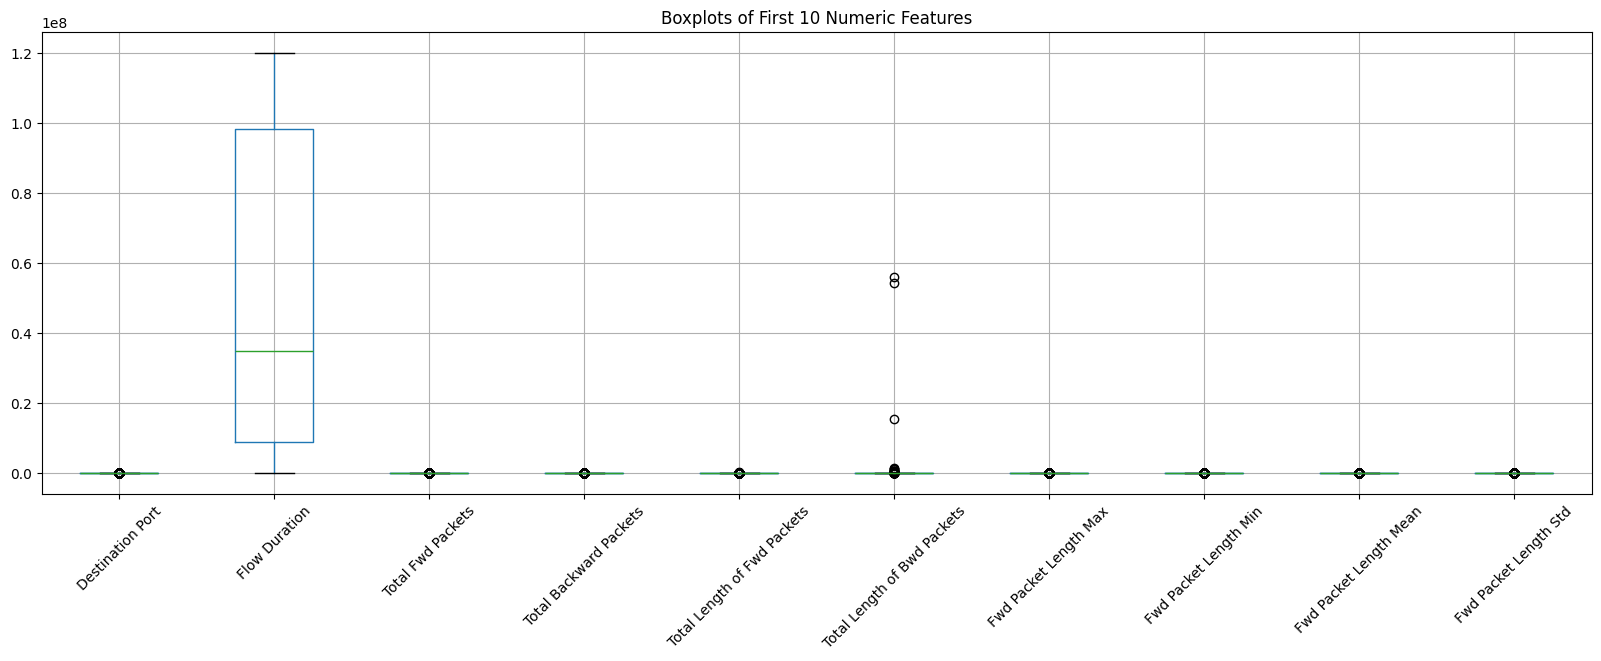

In [19]:
numeric_cols = x.select_dtypes(include=[np.number])

plt.figure(figsize=(20, 6))
numeric_cols.iloc[:, :10].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of First 10 Numeric Features")
plt.show()

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(y_test.value_counts())
scaler = StandardScaler()

# applying IQR only to training data
df_train = pd.concat([x_train, y_train], axis=1)
df_train = remove_outliers_iqr(df_train)

x_train = df_train.drop(columns=["Label"])
y_train = df_train["Label"]

# fill missing values using training median only
x_train = x_train.fillna(x_train.median())
x_test = x_test.fillna(x_train.median())

numeric_cols = x_train.select_dtypes(include=[np.number]).columns

x_train = x_train.copy()
x_test = x_test.copy()

x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

Label
attack    5127
benign     594
Name: count, dtype: int64


In [21]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [22]:
report = classification_report(y_test, y_pred, target_names=["benign", "attack"])
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label="attack")
recall = recall_score(y_test, y_pred, pos_label="attack")
precision = precision_score(y_test, y_pred, pos_label="attack")
cm = confusion_matrix(y_test, y_pred, labels=["benign", "attack"])

print(f"Classification Report:\n{classification_report}")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print("Confusion Matrix:")
print(cm)

Classification Report:
<function classification_report at 0x11b3e8ca0>
Accuracy: 0.9944
F1 Score: 0.9969
Recall: 0.9996
Precision: 0.9942
Confusion Matrix:
[[ 564   30]
 [   2 5125]]


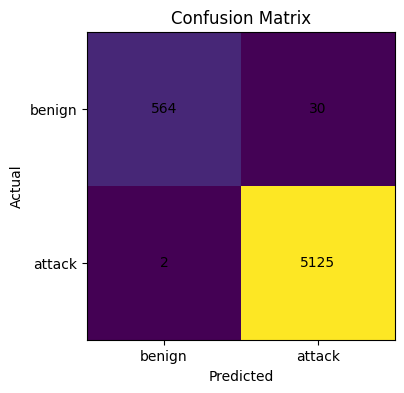

In [23]:
import os

# create folder
os.makedirs("results/plots", exist_ok=True)

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["benign", "attack"])
plt.yticks([0, 1], ["benign", "attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.savefig("results/plots/rf_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()